In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
DATASET_PATH = 'cleaned_dataset.csv'
df = pd.read_csv(DATASET_PATH)
transformed_df = pd.DataFrame()

In [9]:
# def test_std(array:np.array):
#   mean = array.mean()
#   ecart = np.subtract(array, mean)
#   nm_std = np.sqrt(np.divide(np.pow(ecart, 2).sum(), array.shape[0]))
#   exp_std = np.divide(np.abs(np.subtract(array, mean)).sum(), array.shape[0])
  # return nm_std, exp_std
# normal_output, exp_output = test_std(np.arange(-10, 11, 1))

<Axes: xlabel='Hours_Studied', ylabel='Count'>

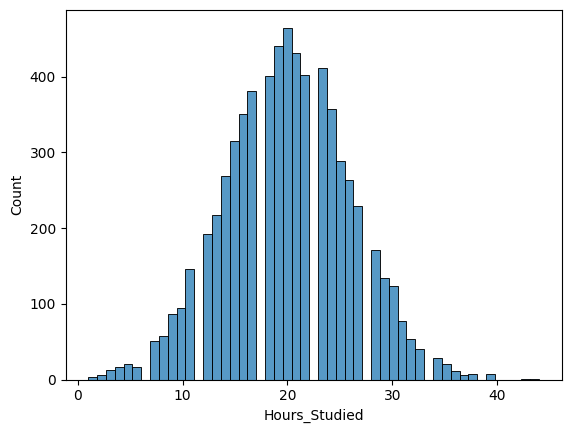

In [10]:
sns.histplot(df['Hours_Studied'])

In [11]:
def calculate_z_score(array:np.array):
  mean = array.mean()
  ecart = np.subtract(array, mean)
  std = np.sqrt(np.divide(np.pow(ecart, 2).sum(), array.shape[0]))
  return np.divide(ecart, std)

def normalize_array(array:np.array):
  min = array.min()
  max = array.max()
  return np.divide(np.subtract(array, min), np.subtract(max, min))

Text(0, 0.5, 'Exam_Score')

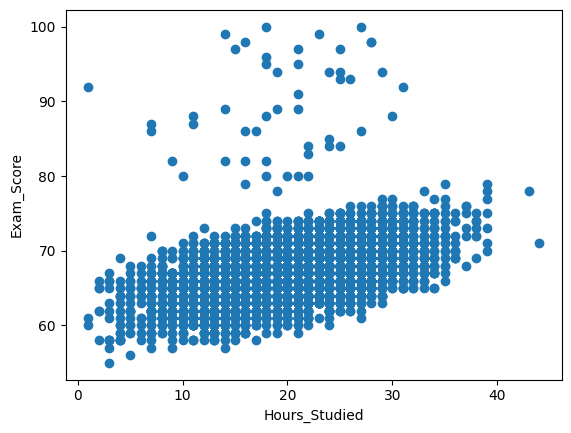

In [12]:
plt.scatter(df['Hours_Studied'].values, df['Exam_Score'].values)
plt.xlabel('Hours_Studied')
plt.ylabel('Exam_Score')

Text(0, 0.5, 'Exam_Score')

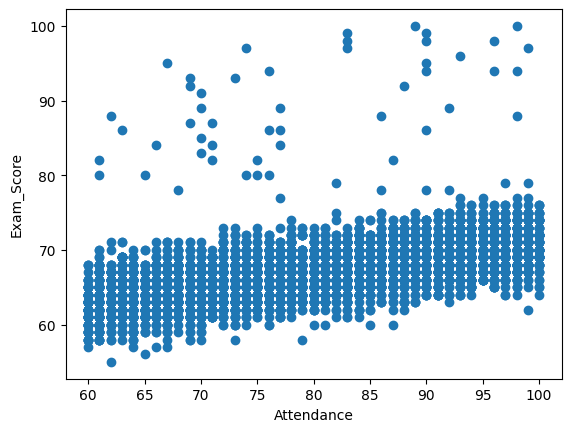

In [13]:
plt.scatter(df['Attendance'].values, df['Exam_Score'].values)
plt.xlabel('Attendance')
plt.ylabel('Exam_Score')

In [14]:
# fig = plt.figure()
# ax = plt.axes(projection='3d')
# ax.plot3D(df['Exam_Score'].values, df['Attendance'].values, df['Hours_Studied'].values, 'red')
# plt.show()

In [15]:
def describe_dataset():
  for column in df.columns:
    nullValues = df[column].isnull()
    duplicated = df[column].duplicated().sum()
    print(f'[+] {column} Column Contain {nullValues.sum()} => {(nullValues.mean()):.2f}% Nulll Values | Duplicates : {duplicated} | DType: {df[column].dtype}')

describe_dataset()

[+] Hours_Studied Column Contain 0 => 0.00% Nulll Values | Duplicates : 6566 | DType: int64
[+] Attendance Column Contain 0 => 0.00% Nulll Values | Duplicates : 6566 | DType: int64
[+] Parental_Involvement Column Contain 0 => 0.00% Nulll Values | Duplicates : 6604 | DType: object
[+] Access_to_Resources Column Contain 0 => 0.00% Nulll Values | Duplicates : 6604 | DType: object
[+] Extracurricular_Activities Column Contain 0 => 0.00% Nulll Values | Duplicates : 6605 | DType: object
[+] Sleep_Hours Column Contain 0 => 0.00% Nulll Values | Duplicates : 6600 | DType: int64
[+] Previous_Scores Column Contain 0 => 0.00% Nulll Values | Duplicates : 6556 | DType: int64
[+] Motivation_Level Column Contain 0 => 0.00% Nulll Values | Duplicates : 6604 | DType: object
[+] Internet_Access Column Contain 0 => 0.00% Nulll Values | Duplicates : 6605 | DType: object
[+] Tutoring_Sessions Column Contain 0 => 0.00% Nulll Values | Duplicates : 6598 | DType: int64
[+] Family_Income Column Contain 0 => 0.00%

In [16]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [17]:
def normalize_int():
  for column in df.columns:
    new_column = f'{column}_Transformed'
    if df[column].dtype == 'int64':
      transformed_df[new_column] = np.float16(normalize_array(df[column].values))
    else:
      mask = (df[column] == 'Low') | (df[column] == 'Medium') | (df[column] == 'High')
      if mask.sum() > 0:
        # low/medium/high
        ids = df[df[column] == 'Low'].index
        transformed_df.loc[ids, new_column] = np.float16(0)
        ids = df[df[column] == 'Medium'].index
        transformed_df.loc[ids, new_column] = np.float16(0.5)
        ids = df[df[column] == 'High'].index
        transformed_df.loc[ids, new_column] = np.float16(1)
        continue
      mask = (df[column] == 'No') | (df[column] == 'Yes')
      if mask.sum() > 0:
        # yes/no
        transformed_df[new_column] = np.int16(np.where(df[column] == 'Yes', 1, 0))
        continue
      mask = (df[column] == 'Public') | (df[column] == 'Private')
      if mask.sum() > 0:
        # public/private
        transformed_df[new_column] = np.int16(np.where(df[column] == 'Public', 1, 0))
        continue
      mask = (df[column] == 'Positive') | (df[column] == 'Negative') | (df[column] == 'Neutral')
      if mask.sum() > 0:
        # postivie/negative/neutral
        ids = df[df[column] == 'Positive'].index
        transformed_df.loc[ids, new_column] = np.int16(1)
        ids = df[df[column] == 'Neutral'].index
        transformed_df.loc[ids, new_column] = np.int16(0)
        ids = df[df[column] == 'Negative'].index
        transformed_df.loc[ids, new_column] = np.int16(-1)
        continue
      mask = (df[column] == 'High School') | (df[column] == 'College') | (df[column] == 'Postgraduate')
      if mask.sum() > 0:
        # school
        ids = df[df[column] == 'High School'].index
        transformed_df.loc[ids, new_column] = np.float16(0)
        ids = df[df[column] == 'College'].index
        transformed_df.loc[ids, new_column] = np.float16(0.5)
        ids = df[df[column] == 'Postgraduate'].index
        transformed_df.loc[ids, new_column] = np.float16(1)
        continue
      mask = (df[column] == 'Near') | (df[column] == 'Moderate') | (df[column] == 'Far')
      if mask.sum() > 0:
        # school
        ids = df[df[column] == 'Near'].index
        transformed_df.loc[ids, new_column] = np.float16(0)
        ids = df[df[column] == 'Moderate'].index
        transformed_df.loc[ids, new_column] = np.float16(0.5)
        ids = df[df[column] == 'Far'].index
        transformed_df.loc[ids, new_column] = np.float16(1)
        continue
      # gender
      transformed_df[new_column] = np.int16(np.where(df[column] == 'Male', 1, 0))
      continue

normalize_int()

In [18]:
# transformed_df.to_csv('transformed_df.csv', index=False, index_label=False, encoding='utf-8')
train_id = int(len(transformed_df) * 0.8)
transformed_df.iloc[:train_id, :].to_csv('train_dataset.csv', index=False, index_label=False, encoding='utf-8')
transformed_df.iloc[train_id:, :].to_csv('test_dataset.csv', index=False, index_label=False, encoding='utf-8')

In [19]:
for column in transformed_df.columns:
  if 'float' in str(transformed_df[column].dtype):
    transformed_df[column] = np.float16(transformed_df[column].values)
  else:
    transformed_df[column] = np.int16(transformed_df[column].values)

In [20]:
for id, column in enumerate(transformed_df.columns):
  print(f'[{id}] {column} | {transformed_df[column].dtype}')

[0] Hours_Studied_Transformed | float16
[1] Attendance_Transformed | float16
[2] Parental_Involvement_Transformed | float16
[3] Access_to_Resources_Transformed | float16
[4] Extracurricular_Activities_Transformed | int16
[5] Sleep_Hours_Transformed | float16
[6] Previous_Scores_Transformed | float16
[7] Motivation_Level_Transformed | float16
[8] Internet_Access_Transformed | int16
[9] Tutoring_Sessions_Transformed | float16
[10] Family_Income_Transformed | float16
[11] Teacher_Quality_Transformed | float16
[12] School_Type_Transformed | int16
[13] Peer_Influence_Transformed | float16
[14] Physical_Activity_Transformed | float16
[15] Learning_Disabilities_Transformed | int16
[16] Parental_Education_Level_Transformed | float16
[17] Distance_from_Home_Transformed | float16
[18] Gender_Transformed | int16
[19] Exam_Score_Transformed | float16


In [21]:
dt = np.dtype([
    ('Hours_Studied_Transformed',  np.float16), ('Attendance_Transformed',  np.float16), ('Parental_Involvement_Transformed',  np.float16), ('Access_to_Resources_Transformed',  np.float16),
    ('Extracurricular_Activities_Transformed',  np.int16),   ('Sleep_Hours_Transformed',  np.float16), ('Previous_Scores_Transformed',  np.float16), ('Motivation_Level_Transformed',  np.float16),
    ('Internet_Access_Transformed',  np.int16),   ('Tutoring_Sessions_Transformed',  np.float16), ('Family_Income_Transformed', np.float16), ('Teacher_Quality_Transformed', np.float16),
    ('School_Type_Transformed', np.int16),   ('Peer_Influence_Transformed', np.float16), ('Physical_Activity_Transformed', np.float16), ('Learning_Disabilities_Transformed', np.int16),
    ('Parental_Education_Level_Transformed', np.float16), ('Distance_from_Home_Transformed', np.float16), ('Gender_Transformed', np.int16),  ('Exam_Score_Transformed', np.float16)
])

In [22]:
dt

dtype([('Hours_Studied_Transformed', '<f2'), ('Attendance_Transformed', '<f2'), ('Parental_Involvement_Transformed', '<f2'), ('Access_to_Resources_Transformed', '<f2'), ('Extracurricular_Activities_Transformed', '<i2'), ('Sleep_Hours_Transformed', '<f2'), ('Previous_Scores_Transformed', '<f2'), ('Motivation_Level_Transformed', '<f2'), ('Internet_Access_Transformed', '<i2'), ('Tutoring_Sessions_Transformed', '<f2'), ('Family_Income_Transformed', '<f2'), ('Teacher_Quality_Transformed', '<f2'), ('School_Type_Transformed', '<i2'), ('Peer_Influence_Transformed', '<f2'), ('Physical_Activity_Transformed', '<f2'), ('Learning_Disabilities_Transformed', '<i2'), ('Parental_Education_Level_Transformed', '<f2'), ('Distance_from_Home_Transformed', '<f2'), ('Gender_Transformed', '<i2'), ('Exam_Score_Transformed', '<f2')])

In [23]:
data = np.empty(len(transformed_df), dtype=dt)

In [24]:
for id, column in enumerate(transformed_df.columns):
  data[column] = transformed_df[column].values

In [25]:
data.tofile('transformed_dataset.bin')

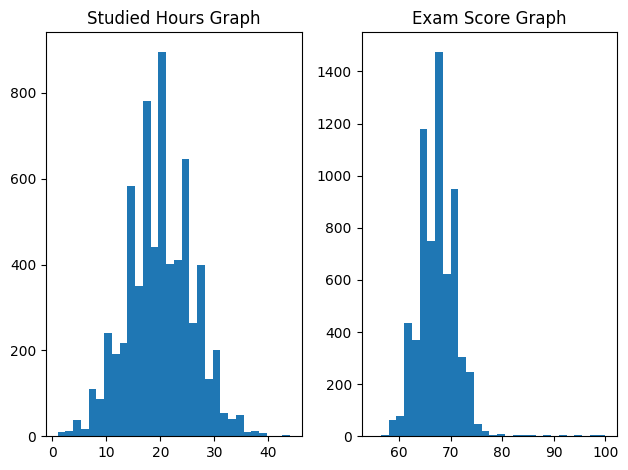

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.hist(df['Hours_Studied'].values, bins=30)
ax1.set_title('Studied Hours Graph')

ax2.hist(df['Exam_Score'].values, bins=30)
ax2.set_title('Exam Score Graph')

plt.tight_layout()
plt.show()

<Axes: >

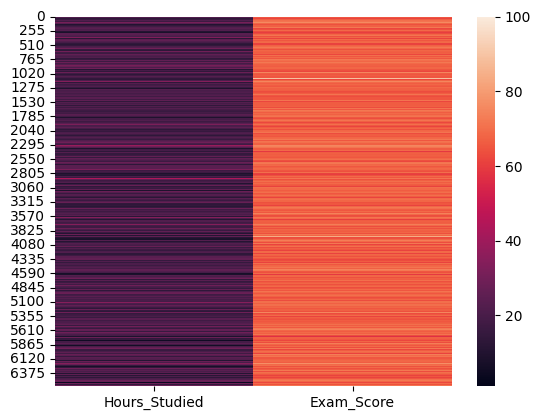

In [27]:
fig = plt.figure()
sns.heatmap(df[['Hours_Studied', 'Exam_Score']])